In [ ]:
import marimo as mo

# Friend Score

Write a query to find PersonID, Name, number of friends, total friend score for every person and who have friends with total score greater than 100.

In [ ]:
_df = mo.sql(
    f"""
    DROP TABLE IF EXISTS friend;

    DROP TABLE IF EXISTS person;

    CREATE TABLE friend (pid INT, fid INT);

    INSERT INTO
    	friend (pid, fid)
    VALUES
    	('1', '2'),
    	('1', '3'),
    	('2', '1'),
    	('2', '3'),
    	('3', '5'),
    	('4', '2'),
    	('4', '3'),
    	('4', '5');

    CREATE TABLE person (personid INT, name VARCHAR(50), score INT);

    INSERT INTO
    	person (personid, name, score)
    VALUES
    	('1', 'Alice', '88'),
    	('2', 'Bob', '11'),
    	('3', 'Devis', '27'),
    	('4', 'Tara', '45'),
    	('5', 'John', '63');
    """
)

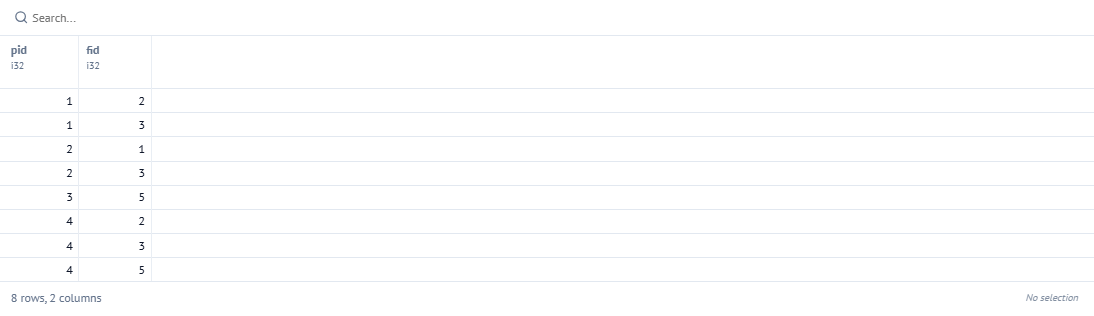

In [ ]:
_df = mo.sql(
    f"""
    SELECT * FROM friend;
    """
)

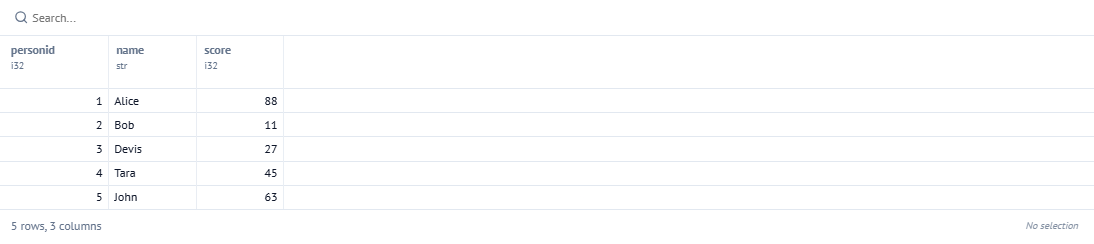

In [ ]:
_df = mo.sql(
    f"""
    SELECT * FROM person;
    """
)

# Solution

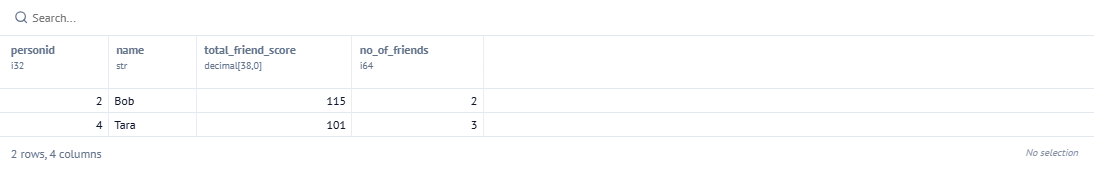

In [ ]:
_df = mo.sql(
    f"""
    WITH
    	getting_friends AS (
    		SELECT
    			f.pid,
    			score AS friend_score
    		FROM
    			person AS p
    			INNER JOIN friend AS f ON p.personid = f.fid
    		ORDER BY
    			1
    	)
    SELECT
    	p.personid,
    	p.name,
    	SUM(friend_score) AS total_friend_score,
    	COUNT(*) AS no_of_friends
    FROM
    	person AS p
    	LEFT JOIN getting_friends AS g ON p.personid = g.pid
    GROUP BY
    	1,
    	2
    HAVING
    	SUM(friend_score) > 100
    ORDER BY
    	1;
    """
)